# GCAP3226 Week 3 — Graded in-class exercise (5%)

**Individual** · submit via **your GitHub fork** (end of notebook). Keep answers short.

### What is marked
| Task | Focus |
|------|--------|
| **1** | Stacked bar: one factor **other than** `government_consideration` vs `support_info` + your trend description |
| **2** | Multiple linear regression that builds on the demo, adding `policy_helpfulness` and `waste_severity` + short coefficient interpretation |
| **3** | **Your own** IPO prompt → simple linear regression: `support_info` vs `fairness` |
| **Submit** | Save → Source Control → **Commit & Push** → **commit message** → Commit → Moodle **GitHub URL** |

Use **association** language only. This is a **non-probability** sample — do not claim causation or “all of Hong Kong”.


## How to use AI here (Codespaces)

In the demo you practiced **Input → Process → Output** prompts (**Write Python code** in Process).

**Tasks 1–2:** the prompt is already in the code cell as comments.

**Task 3:** you **write the prompt yourself** in the comments, then use Inline Chat.

Workflow:
1. Click inside the code cell.  
2. Edit / write the comment prompt.  
3. Press **`Cmd+I`** (Mac) or **`Ctrl+I`** (Windows/Linux).  
4. Ask e.g. *Implement the prompt in the comments above* → **Keep**.  
5. Fix anything that breaks; write interpretations **in your own words**.


## Setup (run once)

Load `week3.csv`. Glance at the column names so you know what you can use.


In [1]:
# Setup — run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression

DATA_FILE = "week3.csv"


def load_week3_data():
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            print("Using data file:", p.resolve())
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Work in your Week 3 fork / Codespace."
    )


df = load_week3_data()
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()


Using data file: /workspaces/GCAP3226_week3/week3.csv
shape: (97, 12)
columns: ['ID', 'support_info', 'support_after_info', 'government_consideration', 'fairness', 'policy_helpfulness', 'waste_severity', 'recycling_effort', 'age_group', 'monthly_income', 'education', 'education_label']


,ID,support_info,support_after_info,government_consideration,fairness,policy_helpfulness,waste_severity,recycling_effort,age_group,monthly_income,education,education_label
0,1,1,1,1,1,1,3,1,29.5,22500.5,4,Master or above
1,2,5,5,5,5,4,2,2,39.5,7500.0,4,Master or above
2,3,3,5,4,5,2,3,1,29.5,22500.5,4,Master or above
3,4,1,2,1,2,2,3,2,29.5,60000.5,4,Master or above
4,5,1,3,3,4,1,3,2,49.5,22500.5,2,Secondary


## Task 1 — Stacked bar (not the demo pair)

In the demo, the stacked bar used **`government_consideration`** (groups) × **`support_info`** (stack, row %).

**Your job:** choose a **different** grouping variable from `week3.csv` and plot a **row-% stacked bar** of `support_info` within each group.

### Suggested grouping variables (pick one)
| Variable | Notes |
|----------|--------|
| `fairness` | 1–5 |
| `policy_helpfulness` | 1–4 |
| `waste_severity` | 1–4 |
| `recycling_effort` | 1–4 |
| `education` | 1–4 |

Do **not** use `government_consideration` as the grouping variable.

In the **next code cell**, replace `<YOUR_GROUP_VAR>` in the comment prompt with your choice, then use Inline Chat (see **How to use AI** above).


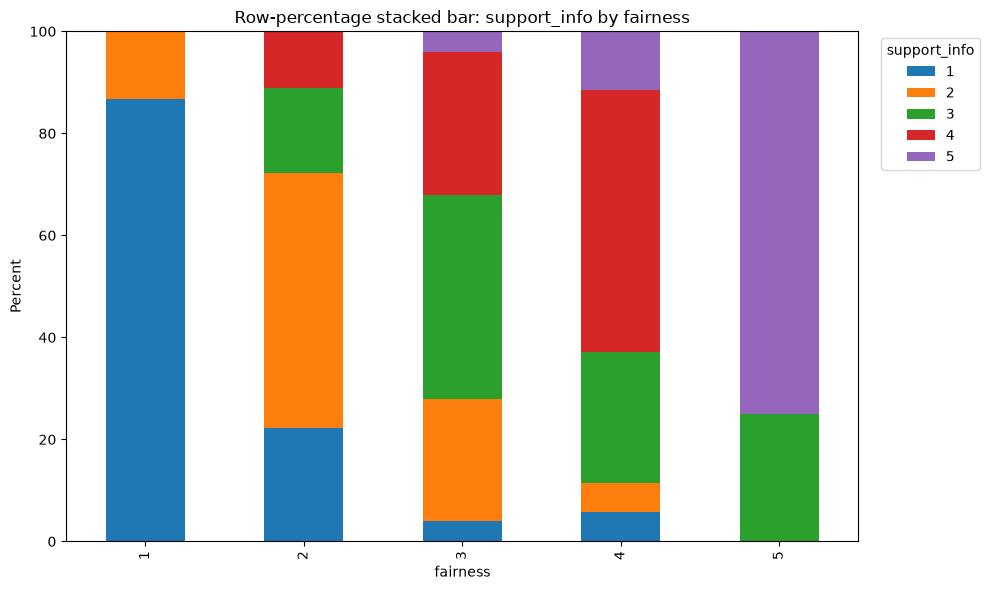

n per fairness group:
fairness
1    15
2    18
3    25
4    35
5     4
Name: count, dtype: int64


In [2]:
# Task 1 — Stacked bar
# --- Sample AI prompt (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to make a row-percentage stacked bar chart of
#   support_info within each level of fairness.
#   Drop rows with missing values for these columns. Show n for each group if you can.
#   Add comments to key Python code.
# Output: A stacked bar chart with title, axis labels, and legend.
# --- End prompt ---
#
# --- generated / your code below ---
# Use fairness as the grouping variable, and plot support_info as the stacked categories
plot_df = df[["fairness", "support_info"]].dropna().copy()
plot_df["fairness"] = plot_df["fairness"].astype(int)

# Create a row-percentage table for each fairness level
counts = plot_df.groupby("fairness")["support_info"].value_counts().unstack(fill_value=0)
row_pct = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart
ax = row_pct.plot(kind="bar", stacked=True, figsize=(10, 6))
ax.set_title("Row-percentage stacked bar: support_info by fairness")
ax.set_xlabel("fairness")
ax.set_ylabel("Percent")
ax.legend(title="support_info", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("n per fairness group:")
print(plot_df["fairness"].value_counts().sort_index())

### Task 1 — Describe the trend (your words)

In 2–4 sentences: what pattern do you see in **this sample**? Use association language. Mention any thin groups (small *n*) if relevant.

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [3]:
# Task 1 — write BETWEEN the triple quotes, then RUN this cell
task1_trend = """In this sample, fairness is positively associated with support_info: respondents who report higher fairness tend to report higher support_info. The pattern is strongest in the middle-to-high fairness categories, while the lowest fairness category has fewer responses and is therefore a thinner comparison group."""
# What trend do you see?

print(task1_trend)


In this sample, fairness is positively associated with support_info: respondents who report higher fairness tend to report higher support_info. The pattern is strongest in the middle-to-high fairness categories, while the lowest fairness category has fewer responses and is therefore a thinner comparison group.


## Task 2 — Multiple linear regression (+ policy & severity)

In the demo you fitted multiple linear regression with `government_consideration` and `fairness` (and a fuller model with demographics).

**Your job:** fit a multiple linear regression for this sample:

**Response:** `support_info`  

**Exploratory variables (at least these four):**
- `government_consideration`
- `fairness`
- `policy_helpfulness`
- `waste_severity`

Use complete cases for these columns. Print **each coefficient**, **R²**, and **n**.  

In the **next code cell**, use the comment prompt with Inline Chat (see **How to use AI** above).


In [4]:
# Task 2 — Multiple linear regression
# Use complete cases on the variables needed for this model.
model_cols = [
    "government_consideration",
    "fairness",
    "policy_helpfulness",
    "waste_severity",
    "support_info",
]

reg_df = df[model_cols].dropna().copy()

X = reg_df[
    ["government_consideration", "fairness", "policy_helpfulness", "waste_severity"]
]
y = reg_df["support_info"]

model = LinearRegression()
model.fit(X, y)

print("Multiple linear regression: support_info ~ government_consideration + fairness + policy_helpfulness + waste_severity")
print("Coefficients:")
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name}: {coef}")
print(f"  Intercept: {model.intercept_}")
print(f"R²: {model.score(X, y)}")
print(f"n: {len(reg_df)}")


Multiple linear regression: support_info ~ government_consideration + fairness + policy_helpfulness + waste_severity
Coefficients:
  government_consideration: 0.4832645758847302
  fairness: 0.37863881949307115
  policy_helpfulness: 0.1924143110526489
  waste_severity: 0.1179674743218849
  Intercept: -0.27679212046097
R²: 0.6387240598479557
n: 97


### Task 2 — Report & briefly interpret

1. Paste or list the **coefficients** (and R², n) from your output.  
2. In a few sentences, interpret **two** coefficients that interest you (association; holding the other variables fixed).  
3. One caution (sample / overclaim).

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [5]:
# Task 2 — write BETWEEN the triple quotes, then RUN this cell
task2_writeup = """Coefficients:
  government_consideration: 0.4832645758847302
  fairness: 0.37863881949307115
  policy_helpfulness: 0.1924143110526489
  waste_severity: 0.1179674743218849
  Intercept: -0.27679212046097
R²: 0.6387240598479557
n: 97

Interpretation:
Holding the other variables fixed, a one-unit increase in government_consideration is associated with a 0.483-unit increase in support_info. Holding the other variables fixed, a one-unit increase in fairness is associated with a 0.379-unit increase in support_info.

Caution:
This is a non-probability sample, so the associations are descriptive and do not establish causation or imply the full population of Hong Kong."""

print(task2_writeup)


Coefficients:
  government_consideration: 0.4832645758847302
  fairness: 0.37863881949307115
  policy_helpfulness: 0.1924143110526489
  waste_severity: 0.1179674743218849
  Intercept: -0.27679212046097
R²: 0.6387240598479557
n: 97

Interpretation:
Holding the other variables fixed, a one-unit increase in government_consideration is associated with a 0.483-unit increase in support_info. Holding the other variables fixed, a one-unit increase in fairness is associated with a 0.379-unit increase in support_info.

Caution:
This is a non-probability sample, so the associations are descriptive and do not establish causation or imply the full population of Hong Kong.


## Task 3 — Write your own prompt (simple linear regression)

**Goal:** `support_info` (response) vs `fairness` (one exploratory variable) — a **simple** linear regression on this sample.

Unlike Tasks 1–2, **do not** copy a ready-made Process. In the **next code cell**, write the full **Input / Process / Output** in the comments (**Process** must include **Write Python code**), then use Inline Chat (see **How to use AI** above).

Keep the model to **these two variables only** (not the Task 2 multiple linear regression). You should get coefficients, R², and n.


In [7]:
# Task 3 — YOUR prompt
# --- Write your AI prompt here (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to fit a simple linear regression with support_info as the response and fairness as the explanatory variable. Use complete cases on these two columns, print the slope, intercept, R², and n, and add comments to key lines.
# Output: The regression coefficients, R², and n.
# --- End prompt ---
# Requirement: simple linear regression only — response = support_info, exploratory = fairness.
#
# --- generated / your code below ---
# Simple linear regression: support_info ~ fairness

simple_df = df[["fairness", "support_info"]].dropna().copy()

X = simple_df[["fairness"]]
y = simple_df["support_info"]

simple_model = LinearRegression()
simple_model.fit(X, y)

print("Simple linear regression: support_info ~ fairness")
print(f"Slope (fairness): {simple_model.coef_[0]}")
print(f"Intercept: {simple_model.intercept_}")
print(f"R²: {simple_model.score(X, y)}")
print(f"n: {len(simple_df)}")


Simple linear regression: support_info ~ fairness
Slope (fairness): 0.7936418962203715
Intercept: 0.49503523382447145
R²: 0.5219498894120836
n: 97


### Task 3 — Short note

In 1–2 sentences: what does the **fairness** slope mean in this simple linear regression? How does it compare (roughly) with the fairness coefficient in your **Task 2** multiple linear regression?

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell.


In [8]:
# Task 3 — write BETWEEN the triple quotes, then RUN this cell
task3_note = """In this simple regression, a one-unit increase in fairness is associated with about a 0.79-unit increase in support_info. This is larger than the fairness coefficient in the Task 2 multiple regression (about 0.38), which is expected because the multiple model adjusts for other variables at the same time."""

print(task3_note)


In this simple regression, a one-unit increase in fairness is associated with about a 0.79-unit increase in support_info. This is larger than the fairness coefficient in the Task 2 multiple regression (about 0.38), which is expected because the multiple model adjusts for other variables at the same time.


## How to submit

Submit the **GitHub URL** of this notebook in **your fork** (not an `.ipynb` upload).

1. **Save** the notebook.  
2. Open **Source Control** (left sidebar, branch icon).  
3. Click **Commit & Push**.  
4. Type a **commit message** → click **Commit**.  
5. On github.com, open the file in **your fork** → copy the browser URL.  
6. Paste that URL on **Moodle**.

**If push fails:** ask a TA — keep working toward a push to your fork.

### Checklist
- [ ] Task 1: stacked bar (not `government_consideration` groups) + trend description  
- [ ] Task 2: multiple linear regression with the four required variables + coefficient write-up  
- [ ] Task 3: **your own** IPO prompt + simple linear regression (`support_info` vs `fairness`)  
- [ ] Saved → Commit & Push → commit message → Commit  
- [ ] Moodle: GitHub link submitted  
